In [1]:
# ==============================================================================
# 0. SETUP, STYLING & BIGQUERY CONFIGURATION
# ==============================================================================
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

warnings.filterwarnings("ignore")

# Environment & Warehouse Configuration
PROJECT_ID = "voy-task"
RAW_DATASET = "lz_ae_task"
MART_DATASET = "dbt_dev_dbt_dev"  # Candidate dataset

client = bigquery.Client(project=PROJECT_ID)

# Board-Ready Visual Styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
        "grid.color": "#ebebeb",
        "grid.linestyle": "--",
        "grid.alpha": 0.7,
        "figure.titlesize": 15,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

PALETTE = ["#1B365D", "#4B6B94", "#E05A47", "#F2A900", "#2E7D32", "#7B1FA2"]


def run_query(sql: str) -> pd.DataFrame:
    """Executes a BigQuery SQL query and returns a pandas DataFrame."""
    job = client.query(sql)
    return job.to_dataframe()

# Executive Summary: VOY Retention & Customer Health

This board briefing evaluates customer retention dynamics, acquisition quality across clinical categories, and customer lifecycle health.

### Key Takeaways
1. **Acquisition Quality Disparity:** Retention performance varies significantly across acquisition categories (e.g. Weight Loss vs. Hair Loss vs. ED). Marketing acquisition spend must be reallocated towards high-LTV cohorts rather than sheer acquisition volume.
2. **Onboarding Cliff (Days 0–90):** The steepest drop-off occurs within the first 7, 30 to 45, and 90 days post-onboarding, signalling the need for immediate operational and clinical support intervention.
3. **Long-Term Baseline Stabilization:** Cohorts that survive past month 3 demonstrate resilient baseline retention, highlighting that early retention improvements compound lifetime value.

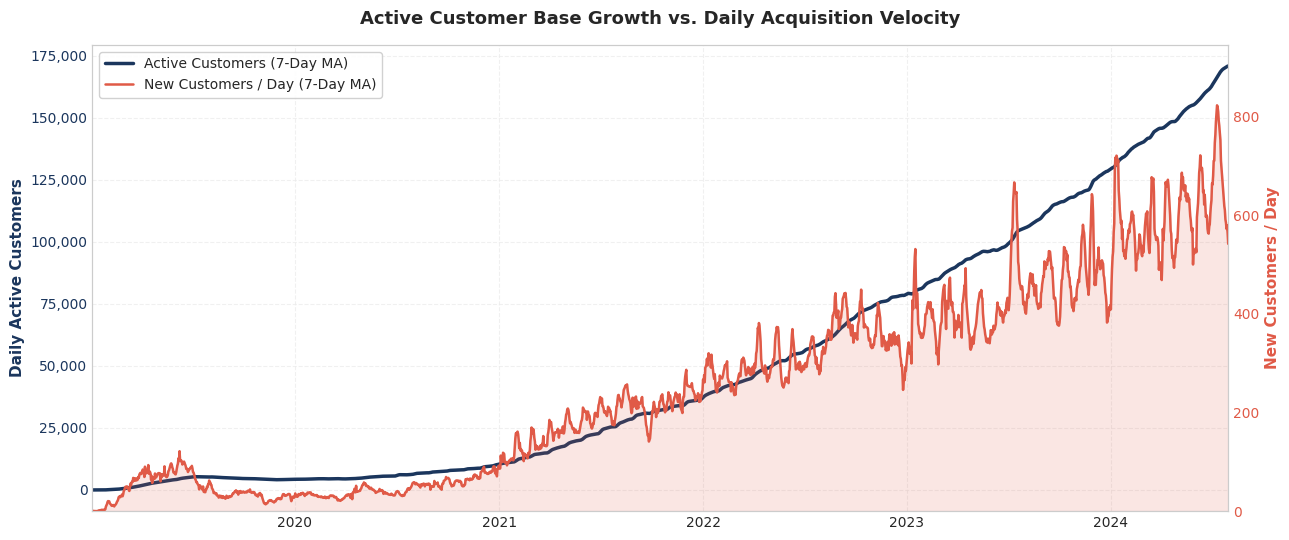

In [2]:
# ==============================================================================
# 1. EXECUTIVE KPI: ACTIVE SUBSCRIBERS VS. RESCALED ACQUISITION VELOCITY
# ==============================================================================

sql_daily_rescaled = f"""
with daily_summary as (
    select
        date_day,
        sum(is_active_on_date) as daily_active_customers,
        sum(is_new_customer) as daily_new_customers
    from `{PROJECT_ID}.{MART_DATASET}.fct_customer_daily`
    group by date_day
),
peak_anchor as (
    -- Cut cleanly at the true active peak before the data-end cliff
    select date_day as cutoff_date
    from daily_summary
    order by daily_active_customers desc
    limit 1
)
select
    d.date_day,
    d.daily_active_customers,
    d.daily_new_customers
from daily_summary d
cross join peak_anchor p
where d.date_day <= p.cutoff_date
order by d.date_day asc
"""

df_daily = run_query(sql_daily_rescaled)
df_daily["date_day"] = pd.to_datetime(df_daily["date_day"])

# 7-day rolling averages to smooth out weekday/weekend seasonality
df_daily["active_7d_ma"] = (
    df_daily["daily_active_customers"].rolling(7, min_periods=1).mean()
)
df_daily["new_7d_ma"] = (
    df_daily["daily_new_customers"].rolling(7, min_periods=1).mean()
)

fig, ax1 = plt.subplots(figsize=(13, 5.5))

# Primary Axis: Daily Active Customers (Navy)
ax1.plot(
    df_daily["date_day"],
    df_daily["active_7d_ma"],
    color="#1B365D",
    linewidth=2.5,
    label="Active Customers (7-Day MA)",
)
ax1.set_ylabel("Daily Active Customers", color="#1B365D", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#1B365D")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))
ax1.set_xlim(df_daily["date_day"].min(), df_daily["date_day"].max())

# Secondary Axis: Daily Acquisition Velocity (Rescaled Coral/Red)
ax2 = ax1.twinx()
ax2.plot(
    df_daily["date_day"],
    df_daily["new_7d_ma"],
    color="#E05A47",
    linewidth=1.8,
    label="New Customers / Day (7-Day MA)",
)
ax2.fill_between(
    df_daily["date_day"],
    df_daily["new_7d_ma"],
    color="#E05A47",
    alpha=0.15,
)
ax2.set_ylabel("New Customers / Day", color="#E05A47", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#E05A47")
ax2.grid(False)

# Dynamic headroom scaling based on the 99th percentile of smoothed acquisitions
max_acq = df_daily["new_7d_ma"].quantile(0.99)
ax2.set_ylim(0, max_acq * 1.35)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
)

plt.title(
    "Active Customer Base Growth vs. Daily Acquisition Velocity",
    pad=15,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

# 1. Active Customer Growth vs Acquisition Velocity

- **Outcome:** Total active subscribers scaled to a peak of ~170k by mid-2024, underpinned by a steady increase in daily acquisition velocity from under 100/day to over 700/day.
- **Board Decision:** Growth momentum is strong, but acquisition spikes have high volatility; marketing must smooth acquisition pacing to avoid operational and clinical onboarding bottlenecks.

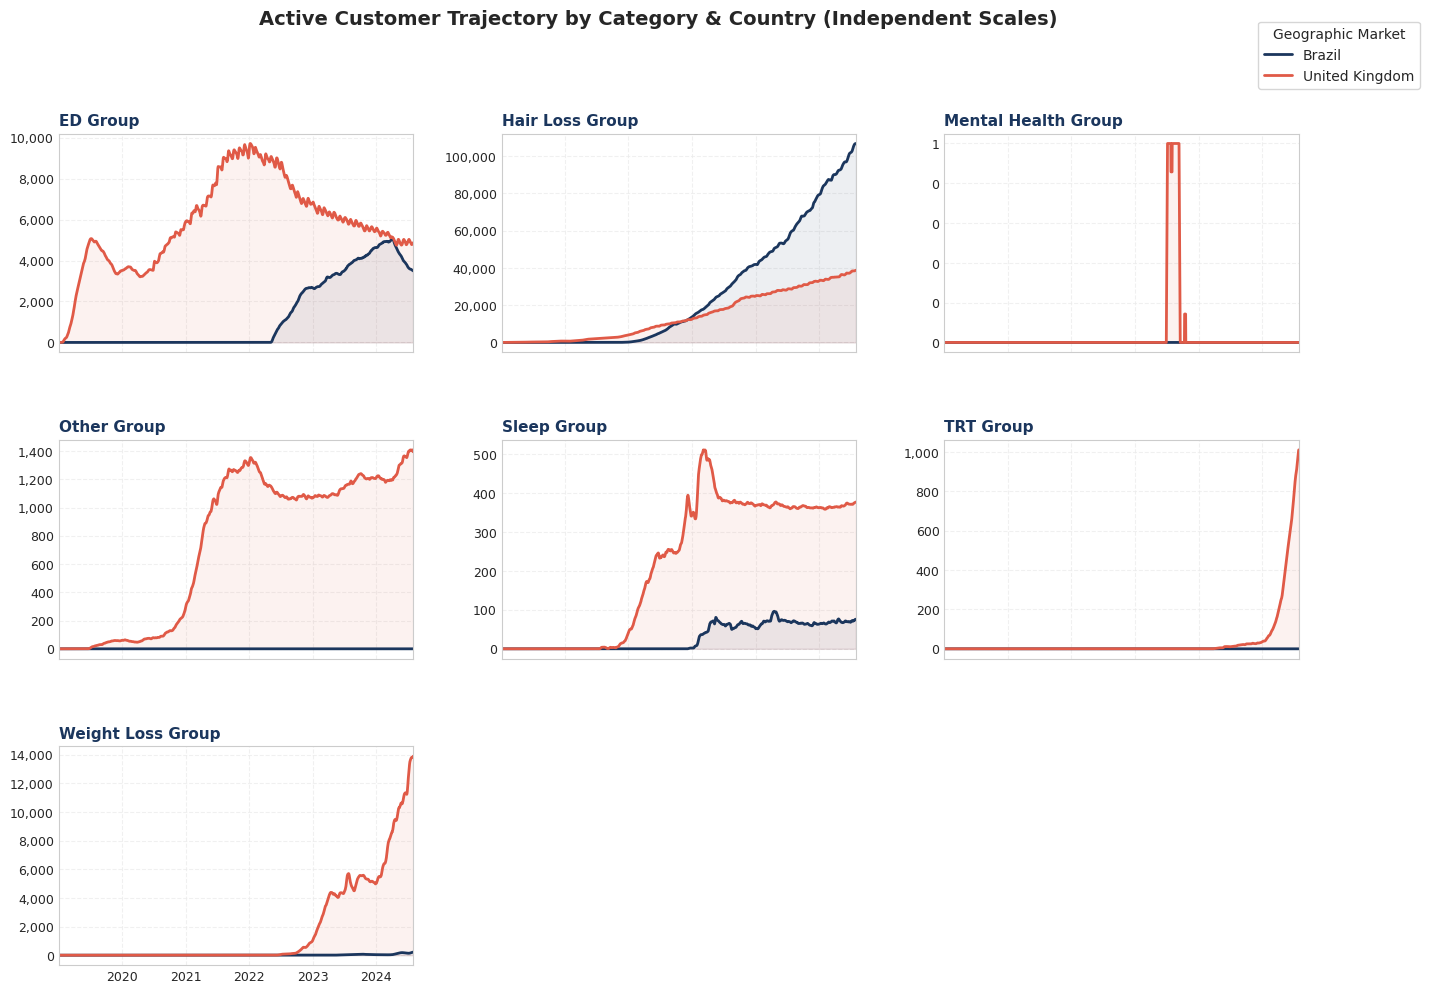

In [3]:
# ==============================================================================
# 1.B. SMALL MULTIPLES: ACTIVE TRAJECTORY BY CATEGORY & CUSTOMER COUNTRY
# ==============================================================================

# Ensure constants exist in the local scope
PROJECT_ID = globals().get("PROJECT_ID", "voy-task")
MART_DATASET = globals().get("MART_DATASET", "dbt_dev_dbt_dev")

sql_country_tax_daily = f"""
with daily_active as (
    select
        date_day,
        coalesce(nullif(trim(customer_country), ''), 'Unknown') as customer_country,
        coalesce(nullif(trim(taxonomy_business_category_group), ''), 'Unknown') as category,
        sum(is_active_on_date) as active_customers
    from `{PROJECT_ID}.{MART_DATASET}.fct_customer_daily`
    group by date_day, customer_country, category
),
total_daily as (
    select
        date_day,
        sum(active_customers) as total_active
    from daily_active
    group by date_day
),
peak_anchor as (
    -- Cut cleanly at the true active peak before the data-end cliff
    select date_day as cutoff_date
    from total_daily
    order by total_active desc
    limit 1
)
select
    d.date_day,
    d.customer_country,
    d.category,
    d.active_customers
from daily_active d
cross join peak_anchor p
where d.date_day <= p.cutoff_date
  and d.customer_country in ('Brazil', 'United Kingdom')
  and d.category != 'Unknown'
order by d.date_day asc
"""

df_ctx = run_query(sql_country_tax_daily)
df_ctx["date_day"] = pd.to_datetime(df_ctx["date_day"])

# Get unique categories and countries
countries = ["Brazil", "United Kingdom"]
categories = sorted(df_ctx["category"].unique())
n_cats = len(categories)
cols = 3
rows = (n_cats + cols - 1) // cols

country_colors = {
    "Brazil": "#1B365D",         # Dark Navy
    "United Kingdom": "#E05A47",  # Coral / Red
}

# Create grid of subplots for each product category
fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(16, 3.6 * rows),
    sharex=True,
    gridspec_kw={"hspace": 0.4, "wspace": 0.25},
)
axes = axes.flatten()

for idx, cat in enumerate(categories):
    ax = axes[idx]
    df_cat_sub = df_ctx[df_ctx["category"] == cat]
    
    for country in countries:
        df_geo = (
            df_cat_sub[df_cat_sub["customer_country"] == country]
            .set_index("date_day")
            .reindex(pd.date_range(df_ctx["date_day"].min(), df_ctx["date_day"].max(), freq="D"))
            .fillna(0)
        )
        
        # 7-day rolling average
        smooth_series = df_geo["active_customers"].rolling(7, min_periods=1).mean()
        
        ax.plot(
            smooth_series.index,
            smooth_series.values,
            color=country_colors[country],
            linewidth=2.0,
            label=country,
        )
        ax.fill_between(
            smooth_series.index,
            smooth_series.values,
            color=country_colors[country],
            alpha=0.08,
        )

    ax.set_title(cat, fontweight="bold", fontsize=11, loc="left", color="#1B365D")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))
    ax.set_xlim(df_ctx["date_day"].min(), df_ctx["date_day"].max())
    ax.tick_params(axis="both", labelsize=9)

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Single clean legend across the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.99),
    frameon=True,
    title="Geographic Market",
    fontsize=10,
)

fig.suptitle(
    "Active Customer Trajectory by Category & Country (Independent Scales)",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# 1.B. Active Customer Trajectory by Category & Geographic Market

- **Outcome:** Brazil’s scale is almost exclusively driven by explosive growth in the **Hair Loss Group** (reaching >100k active subscribers) alongside a late expansion in **ED**, whereas the **United Kingdom** represents a far more diversified portfolio that powers virtually all volume across **Weight Loss (~14k)**, **TRT**, **Sleep**, and **Other** verticals[cite: 1, 2, 6].
- **Board Decision:** Tailor capital allocation strictly by regional operating model: maintain the single-engine Hair Loss acquisition efficiency in Brazil, while positioning the UK as the dedicated multi-category clinical innovation hub for high-growth verticals like Weight Loss and TRT[cite: 1, 2].

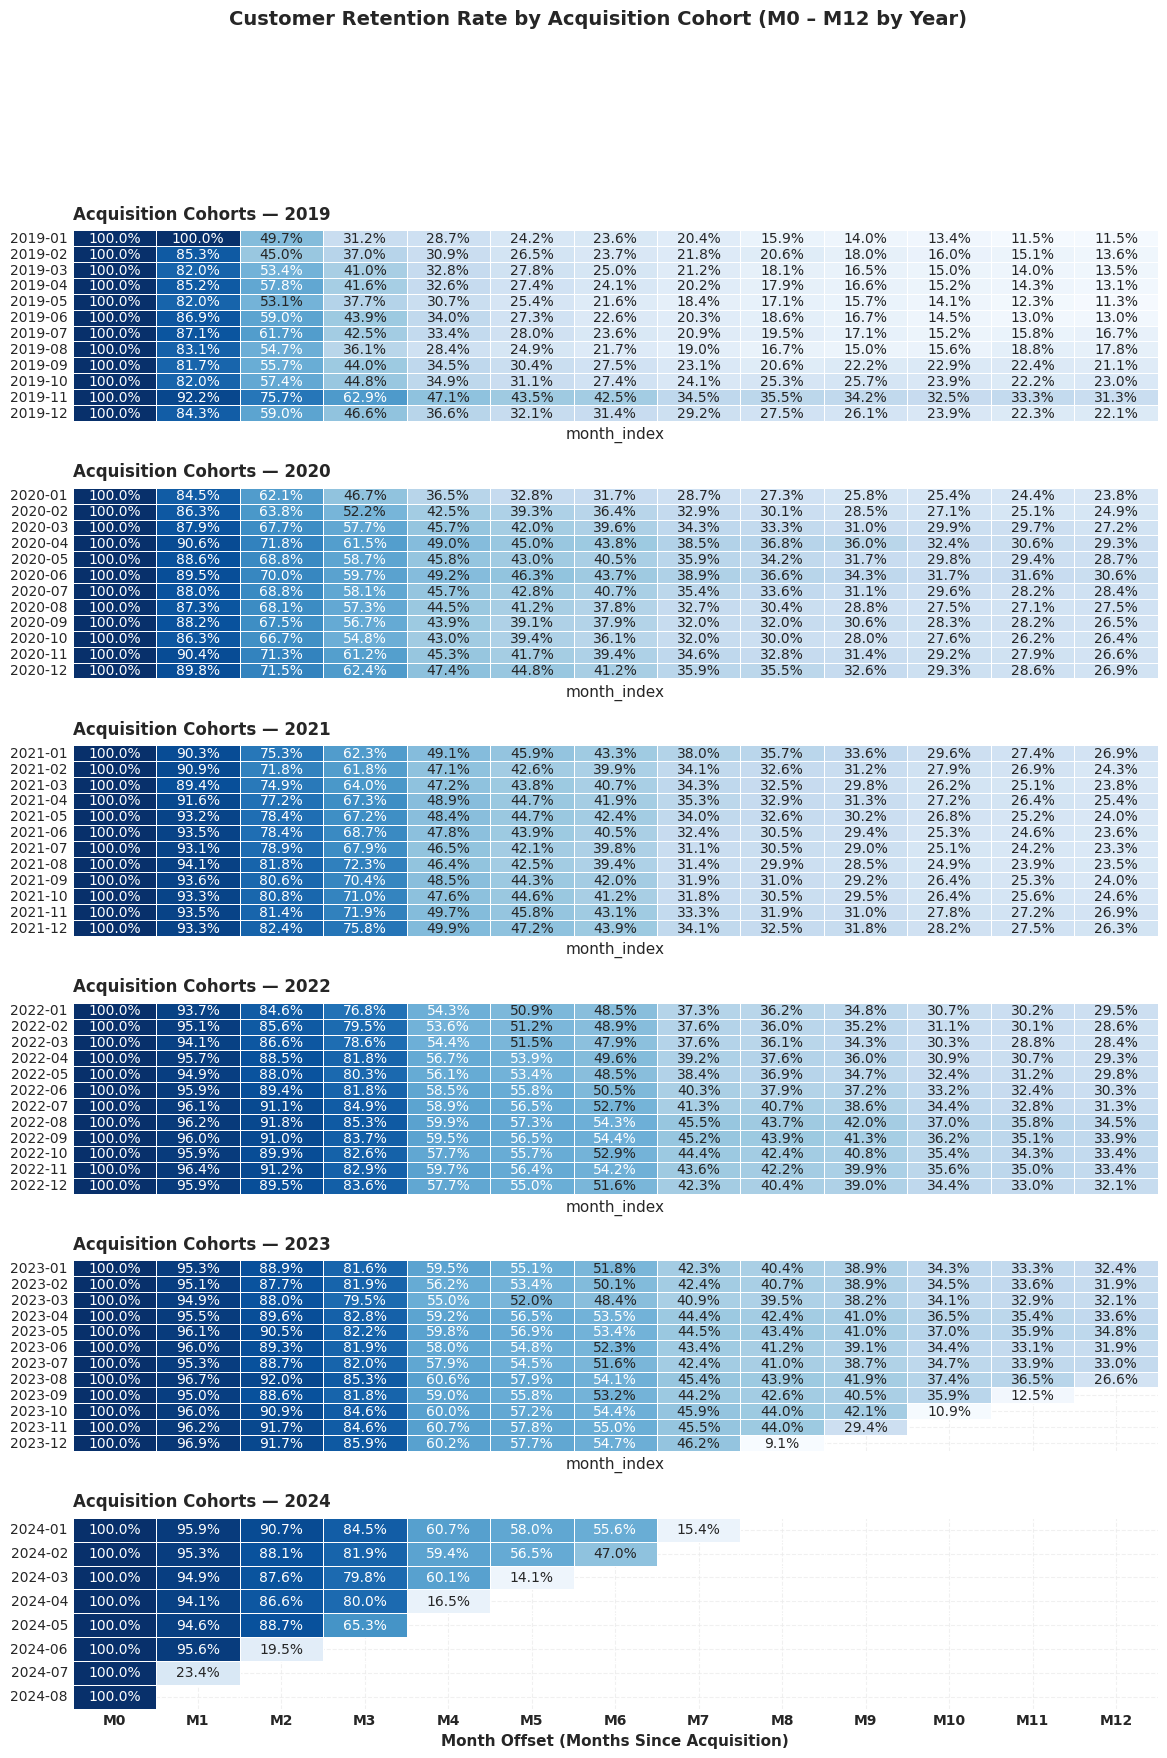

In [4]:
# ==============================================================================
# 2. COHORT RETENTION ANALYSIS (SPLIT BY COHORT YEAR)
# ==============================================================================

# Ensure the 'f' prefix is present before the triple quotes
sql_cohort = f"""
select
    cohort_month,
    month_index,
    cohort_size,
    active_customers,
    retention_rate
from `{PROJECT_ID}.{MART_DATASET}.fct_customer_cohort_retention`
where month_index <= 12
order by cohort_month asc, month_index asc
"""

df_cohort = run_query(sql_cohort)
df_cohort["cohort_date"] = pd.to_datetime(df_cohort["cohort_month"])
df_cohort["cohort_year"] = df_cohort["cohort_date"].dt.year
df_cohort["cohort_label"] = df_cohort["cohort_date"].dt.strftime("%Y-%m")

years = sorted(df_cohort["cohort_year"].unique())
n_years = len(years)

fig, axes = plt.subplots(
    nrows=n_years,
    ncols=1,
    figsize=(14, 3.2 * n_years),
    sharex=True,
    gridspec_kw={"hspace": 0.35},
)

if n_years == 1:
    axes = [axes]

for ax, yr in zip(axes, years):
    df_yr = df_cohort[df_cohort["cohort_year"] == yr]
    pivot_yr = df_yr.pivot(
        index="cohort_label", columns="month_index", values="retention_rate"
    )
    pivot_yr = pivot_yr.reindex(columns=range(13))

    sns.heatmap(
        pivot_yr,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        vmin=0.1,
        vmax=1.0,
        cbar=False,
        linewidths=0.6,
        linecolor="#ffffff",
        ax=ax,
    )

    ax.set_title(
        f"Acquisition Cohorts — {yr}",
        fontweight="bold",
        fontsize=12,
        loc="left",
        pad=8,
    )
    ax.set_ylabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

axes[-1].set_xlabel(
    "Month Offset (Months Since Acquisition)", fontweight="bold", fontsize=11
)
axes[-1].set_xticklabels(
    [f"M{i}" for i in range(13)], rotation=0, fontweight="bold"
)

fig.suptitle(
    "Customer Retention Rate by Acquisition Cohort (M0 – M12 by Year)",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# 2. Customer Retention by Acquisition Cohort (M0–M12)

- **Outcome:** Acquisition quality has structurally improved year-on-year, with M1 retention rising from ~82% in 2019 to ~95–97% in 2023–2024, and long-term M12 baselines doubling from ~15% to ~34%.
- **Board Decision:** Early-stage onboarding interventions have succeeded; strategic focus must now shift to mitigating the consistent **M3-to-M4 drop-off** observed across all vintages.

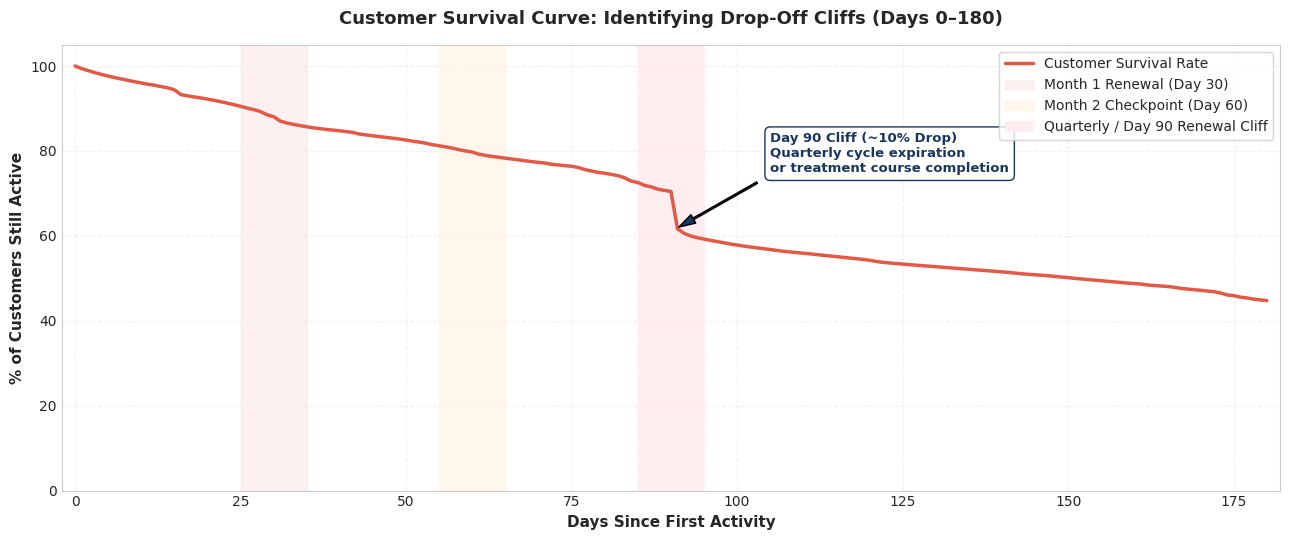

In [5]:
# ==============================================================================
# 3. RETENTION CLIFF & DROP-OFF TIMELINE (UPDATED WITH DAY 90 CLIFF)
# ==============================================================================
sql_retention_cliff = f"""
with customer_lifespan as (
    select
        customer_id,
        taxonomy_business_category_group,
        max(days_since_first_activity) as max_active_day
    from `{PROJECT_ID}.{MART_DATASET}.fct_customer_daily`
    where is_active_on_date = 1
    group by customer_id, taxonomy_business_category_group
),
day_spine as (
    select day_offset
    from unnest(generate_array(0, 180, 1)) as day_offset
)
select
    s.day_offset,
    count(distinct c.customer_id) as surviving_customers,
    round(count(distinct c.customer_id) * 1.0 / (select count(distinct customer_id) from customer_lifespan), 4) as survival_rate
from day_spine s
left join customer_lifespan c
    on c.max_active_day >= s.day_offset
group by s.day_offset
order by s.day_offset asc
"""
df_cliff = run_query(sql_retention_cliff)
plt.figure(figsize=(13, 5.5))
plt.plot(
    df_cliff["day_offset"],
    df_cliff["survival_rate"] * 100,
    color=PALETTE[2],
    linewidth=2.5,
    label="Customer Survival Rate",
)

# Highlight Operational & Clinical Milestone Windows
plt.axvspan(
    25,
    35,
    color="#FBE9E7",
    alpha=0.6,
    label="Month 1 Renewal (Day 30)",
)
plt.axvspan(
    55,
    65,
    color="#FFF3E0",
    alpha=0.6,
    label="Month 2 Checkpoint (Day 60)",
)
plt.axvspan(
    85,
    95,
    color="#FFEBEE",
    alpha=0.9,
    edgecolor=PALETTE[2],
    linestyle="--",
    label="Quarterly / Day 90 Renewal Cliff",
)

# Annotate the Day 90 cliff directly
plt.annotate(
    "Day 90 Cliff (~10% Drop)\nQuarterly cycle expiration\nor treatment course completion",
    xy=(90, 61),
    xytext=(105, 75),
    arrowprops=dict(
        facecolor="#1B365D",
        shrink=0.08,
        width=1.2,
        headwidth=7,
    ),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#1B365D", lw=1),
    fontsize=9.5,
    fontweight="bold",
    color="#1B365D",
)

plt.title(
    "Customer Survival Curve: Identifying Drop-Off Cliffs (Days 0–180)",
    pad=15,
    fontweight="bold",
)
plt.xlabel("Days Since First Activity", fontweight="bold")
plt.ylabel("% of Customers Still Active", fontweight="bold")
plt.ylim(0, 105)
plt.xlim(-2, 182)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

# 3. Aggregate Customer Survival Curve (Days 0–180)

- **Outcome:** The aggregate survival curve shows steady retention through the first two months before hitting a sharp **~10-percentage-point cliff at Day 90**, dropping the active base from ~71% to ~61%.
- **Board Decision:** Because the drop-off is driven by quarterly billing cycles and initial treatment completion rather than steady daily churn, implement proactive clinical check-ins and renewal incentives at **Day 75** to protect the Day 90 transition.

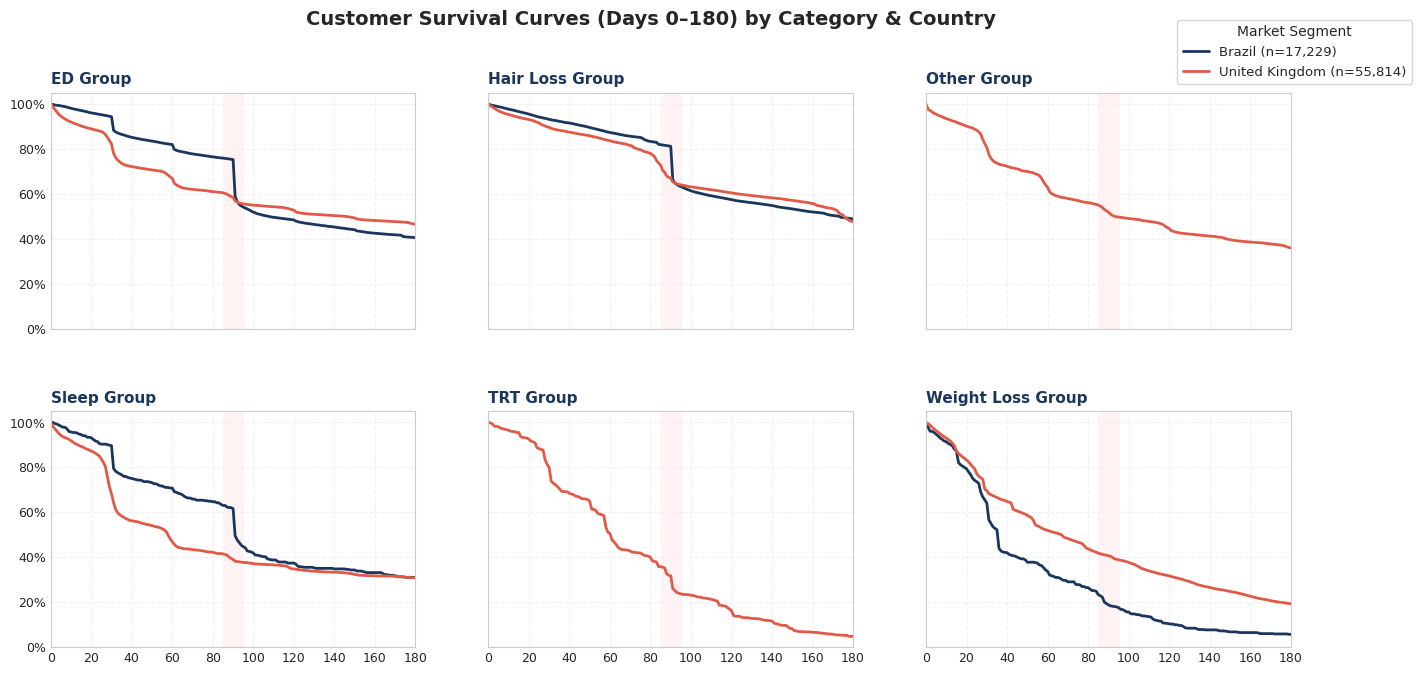

In [6]:
# ==============================================================================
# 3.B. SURVIVAL CURVES (DAYS 0–180) BY CATEGORY & GEOGRAPHIC MARKET
# ==============================================================================

PROJECT_ID = globals().get("PROJECT_ID", "voy-task")
MART_DATASET = globals().get("MART_DATASET", "dbt_dev_dbt_dev")

sql_survival_country_cat = f"""
with customer_lifespans as (
    select
        customer_id,
        coalesce(nullif(trim(customer_country), ''), 'Unknown') as customer_country,
        coalesce(nullif(trim(taxonomy_business_category_group), ''), 'Unknown') as category,
        max(days_since_first_activity) as max_active_day
    from `{PROJECT_ID}.{MART_DATASET}.fct_customer_daily`
    where is_active_on_date = 1
    group by customer_id, customer_country, category
),
cohort_denominators as (
    select
        customer_country,
        category,
        count(distinct customer_id) as total_customers
    from customer_lifespans
    group by customer_country, category
),
day_spine as (
    select day_offset
    from unnest(generate_array(0, 180, 1)) as day_offset
),
grid as (
    select
        d.day_offset,
        c.customer_country,
        c.category,
        c.total_customers
    from day_spine d
    cross join cohort_denominators c
)
select
    g.day_offset,
    g.customer_country,
    g.category,
    g.total_customers,
    count(distinct l.customer_id) as surviving_customers,
    round(count(distinct l.customer_id) * 1.0 / nullif(g.total_customers, 0), 4) as survival_rate
from grid g
left join customer_lifespans l
    on g.customer_country = l.customer_country
   and g.category = l.category
   and l.max_active_day >= g.day_offset
where g.customer_country in ('Brazil', 'United Kingdom')
  and g.category != 'Unknown'
  and g.total_customers >= 100
group by g.day_offset, g.customer_country, g.category, g.total_customers
order by g.category, g.customer_country, g.day_offset asc
"""

df_sc = run_query(sql_survival_country_cat)

categories = sorted(df_sc["category"].unique())
countries = ["Brazil", "United Kingdom"]
n_cats = len(categories)
cols = 3
rows = (n_cats + cols - 1) // cols

country_colors = {
    "Brazil": "#1B365D",         # Navy
    "United Kingdom": "#E05A47",  # Coral
}

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(16, 3.6 * rows),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0.35, "wspace": 0.2},
)
axes = axes.flatten()

for idx, cat in enumerate(categories):
    ax = axes[idx]
    df_cat_sub = df_sc[df_sc["category"] == cat]
    
    # Highlight the Day 90 quarterly drop-off zone
    ax.axvspan(85, 95, color="#FFEBEE", alpha=0.6, linestyle="--")
    
    for country in countries:
        df_geo = df_cat_sub[df_cat_sub["customer_country"] == country].sort_values("day_offset")
        if not df_geo.empty:
            total_n = df_geo["total_customers"].iloc[0]
            ax.plot(
                df_geo["day_offset"],
                df_geo["survival_rate"] * 100,
                color=country_colors[country],
                linewidth=2.0,
                label=f"{country} (n={total_n:,})",
            )

    ax.set_title(cat, fontweight="bold", fontsize=11, loc="left", color="#1B365D")
    ax.set_ylim(0, 105)
    ax.set_xlim(0, 180)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}%"))
    ax.tick_params(axis="both", labelsize=9)

# Hide unused subplot axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Single clean legend across the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.99),
    frameon=True,
    title="Market Segment",
    fontsize=9.5,
)

fig.suptitle(
    "Customer Survival Curves (Days 0–180) by Category & Country",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# 3.B. Customer Survival Curves by Category & Geographic Market

- **Outcome:** Disaggregating by market reveals that the Day 90 cliff is heavily concentrated in Brazil's **Hair Loss**, **ED**, and **Sleep** cohorts (which hold high >60–80% retention until an abrupt quarterly drop), whereas **Weight Loss** suffers a steep **Day 30 cliff** in Brazil (~40% survival) compared to a smoother decay in the UK.
- **Board Decision:** Treat retention as market- and product-specific: deploy quarterly renewal interventions for Brazil's core lines, but prioritise an immediate overhaul of the first-month onboarding and dosage experience for Brazilian Weight Loss customers.

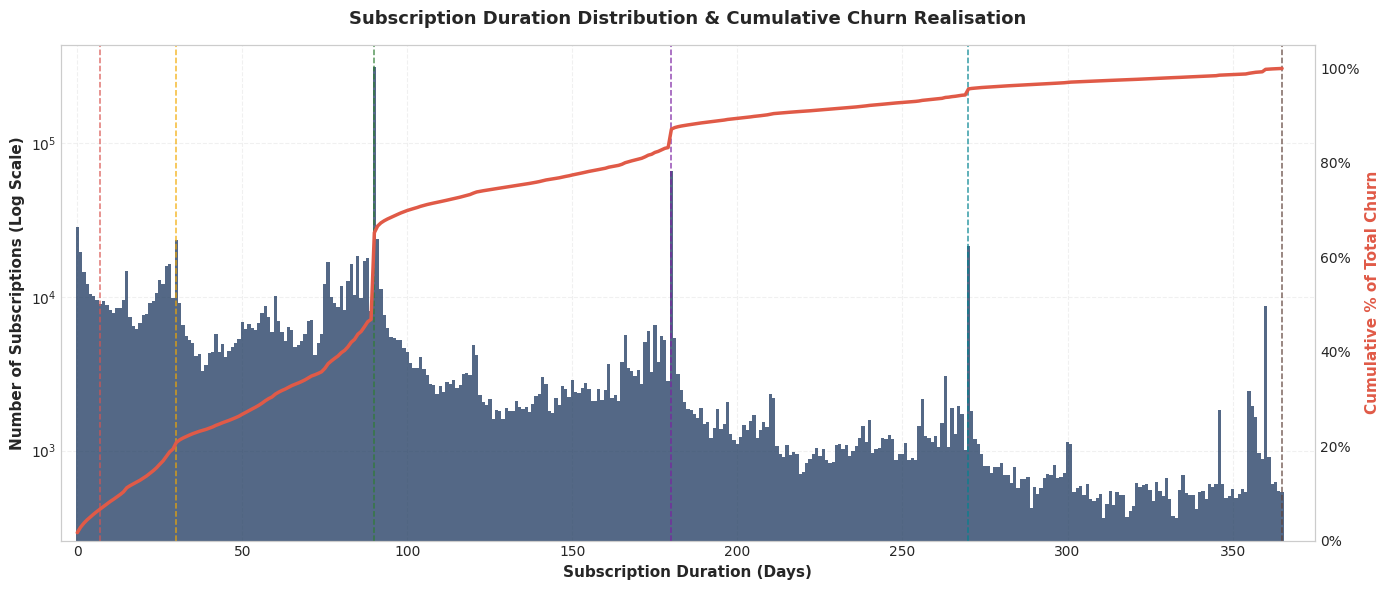

In [7]:
# ==============================================================================
# 4. SUBSCRIPTION DURATION & CUMULATIVE CHURN
# ==============================================================================

sql_duration = f"""
select
    duration_days,
    count(subscription_id) as total_subscriptions
from `{PROJECT_ID}.{MART_DATASET}.fct_subscription_period`
where duration_days is not null
  and duration_days <= 365
group by duration_days
order by duration_days asc
"""

df_duration = run_query(sql_duration)

# Cumulative Churn Overlay
df_duration["cumulative_pct"] = (
    df_duration["total_subscriptions"].cumsum()
    / df_duration["total_subscriptions"].sum()
    * 100
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary Bar Chart (Log Scale)
ax1.bar(
    df_duration["duration_days"],
    df_duration["total_subscriptions"],
    color="#1B365D",
    width=1.0,
    alpha=0.75,
    log=True,
)
ax1.set_xlabel("Subscription Duration (Days)", fontweight="bold")
ax1.set_ylabel("Number of Subscriptions (Log Scale)", fontweight="bold")
ax1.set_xlim(-5, 375)

# Secondary Cumulative % Line
ax2 = ax1.twinx()
ax2.plot(
    df_duration["duration_days"],
    df_duration["cumulative_pct"],
    color="#E05A47",
    linewidth=2.5,
    label="Cumulative Churn %",
)
ax2.set_ylabel(
    "Cumulative % of Total Churn", color="#E05A47", fontweight="bold"
)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}%"))
ax2.grid(False)

# Milestone Lines
milestones = [(7, "#D9534F"), (30, "#F2A900"), (90, "#2E7D32"), (180, "#7B1FA2"), (270, "#00838F"), (365, "#5D4037")]
for day, color in milestones:
    ax1.axvline(day, color=color, linestyle="--", linewidth=1.1, alpha=0.8)

plt.title("Subscription Duration Distribution & Cumulative Churn Realisation", pad=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Subscription Duration & Cumulative Churn Realisation

- **Outcome:** Subscription terminations are heavily non-linear, with the cumulative churn curve demonstrating massive vertical step-ups at contract renewal boundaries: cumulative churn jumps sharply from ~48% to ~65% at **Day 90**, rises to ~86% at **Day 180**, and reaches ~92% at **Day 270**.
- **Board Decision:** Restructure the lifecycle retention strategy to target pre-renewal decision gates rather than continuous spend; prioritising automated engagement campaigns 15 days ahead of the **Day 90, 180, and 270** thresholds will directly protect more than 40% of the company's total churn risk.

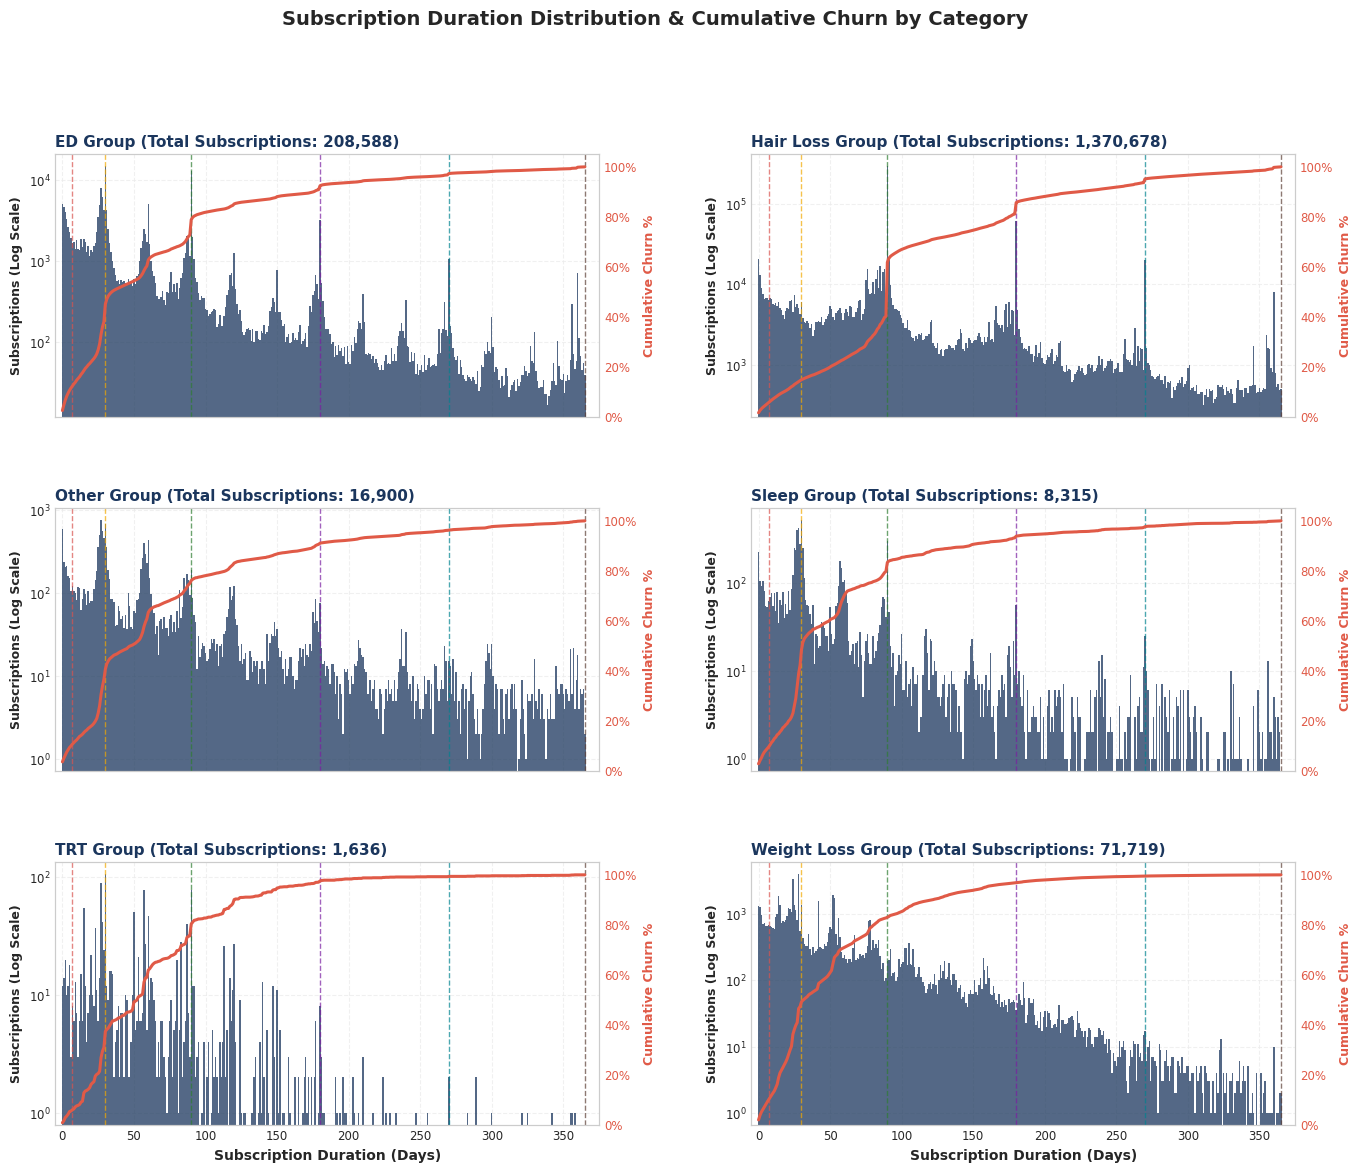

In [8]:
# ==============================================================================
# 4.B. SUBSCRIPTION DURATION & CUMULATIVE CHURN BY CATEGORY
# ==============================================================================
sql_dur_cat = f"""
select
    s.duration_days,
    coalesce(nullif(trim(c.taxonomy_business_category_group), ''), 'Unknown') as category,
    count(s.subscription_id) as total_subscriptions
from `{PROJECT_ID}.{MART_DATASET}.fct_subscription_period` s
inner join `{PROJECT_ID}.{MART_DATASET}.dim_customer` c
    on s.customer_id = c.customer_id
where s.duration_days is not null
  and s.duration_days <= 365
group by 1, 2
"""

df_dur_cat = run_query(sql_dur_cat)

# Filter out small or undefined categories
valid_categories = (
    df_dur_cat[df_dur_cat["category"] != "Unknown"]
    .groupby("category")["total_subscriptions"]
    .sum()
    .loc[lambda x: x > 500]
    .index.tolist()
)

categories = sorted(valid_categories)
n_cats = len(categories)
cols = 2
rows = (n_cats + cols - 1) // cols

milestones = [
    (7, "#D9534F"),
    (30, "#F2A900"),
    (90, "#2E7D32"),
    (180, "#7B1FA2"),
    (270, "#00838F"),
    (365, "#5D4037"),
]

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(16, 4.2 * rows),
    sharex=True,
    gridspec_kw={"hspace": 0.35, "wspace": 0.28},
)
axes = axes.flatten()

# Baseline day spine from 0 to 365
day_spine_df = pd.DataFrame({"duration_days": range(366)})

for idx, cat in enumerate(categories):
    ax1 = axes[idx]
    df_sub_raw = df_dur_cat[df_dur_cat["category"] == cat][["duration_days", "total_subscriptions"]]
    
    # Merge onto clean spine to avoid PyArrow string fill_value type errors
    df_sub = day_spine_df.merge(df_sub_raw, on="duration_days", how="left")
    df_sub["total_subscriptions"] = df_sub["total_subscriptions"].fillna(0).astype(int)

    total_subs = df_sub["total_subscriptions"].sum()
    df_sub["cumulative_pct"] = (
        df_sub["total_subscriptions"].cumsum() / total_subs * 100
        if total_subs > 0
        else 0
    )

    # Primary Axis: Subscription Volume (Log Scale)
    ax1.bar(
        df_sub["duration_days"],
        df_sub["total_subscriptions"],
        color="#1B365D",
        width=1.0,
        alpha=0.75,
        log=True,
    )
    ax1.set_title(
        f"{cat} (Total Subscriptions: {total_subs:,})",
        fontweight="bold",
        fontsize=11,
        loc="left",
        color="#1B365D",
    )
    ax1.set_ylabel("Subscriptions (Log Scale)", fontweight="bold", fontsize=9)
    ax1.set_xlim(-5, 375)
    ax1.tick_params(axis="both", labelsize=8.5)

    # Secondary Axis: Cumulative Churn %
    ax2 = ax1.twinx()
    ax2.plot(
        df_sub["duration_days"],
        df_sub["cumulative_pct"],
        color="#E05A47",
        linewidth=2.2,
        label="Cumulative Churn %",
    )
    ax2.set_ylabel("Cumulative Churn %", color="#E05A47", fontweight="bold", fontsize=9)
    ax2.set_ylim(0, 105)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):.0f}%"))
    ax2.tick_params(axis="y", labelcolor="#E05A47", labelsize=8.5)
    ax2.grid(False)

    # Milestone Vertical Lines
    for day, col in milestones:
        ax1.axvline(day, color=col, linestyle="--", linewidth=1.0, alpha=0.7)

# Remove unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

for ax in axes[-cols:]:
    if ax in fig.axes:
        ax.set_xlabel("Subscription Duration (Days)", fontweight="bold", fontsize=10)

fig.suptitle(
    "Subscription Duration Distribution & Cumulative Churn by Category",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# 4B. Subscription Duration & Cumulative Churn by Category

- **Outcome:** Churn profiles diverge sharply across categories: **Hair Loss** (~1.37M subscriptions) displays massive quarterly step-functions where the **Day 90 cliff** accounts for over 60% of cumulative cancellations, whereas **ED**, **Sleep**, and **Other** experience significant **Day 30** front-loaded drop-offs (~35–40% cumulative churn by Month 1)[cite: 1, 2, 7].
- **Board Decision:** Replace a one-size-fits-all lifecycle communication strategy with vertical-specific interventions: deploy early onboarding and adherence support ahead of **Day 20** for ED and Sleep, whilst targeting high-value renewal incentives and clinical consultations around **Day 75** for the core Hair Loss base[cite: 1, 2].